In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [12]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [13]:
# Fill numeric columns with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_763/2863756049.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_763/2863756049.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [14]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object" or str(df[col].dtype) == "category":
        df[col] = encoder.fit_transform(df[col].astype(str))

In [15]:
X = df.drop("survived", axis=1)

y = df["survived"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
predictions = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [20]:
print(confusion_matrix(y_test, predictions))

[[105   0]
 [  0  74]]


In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



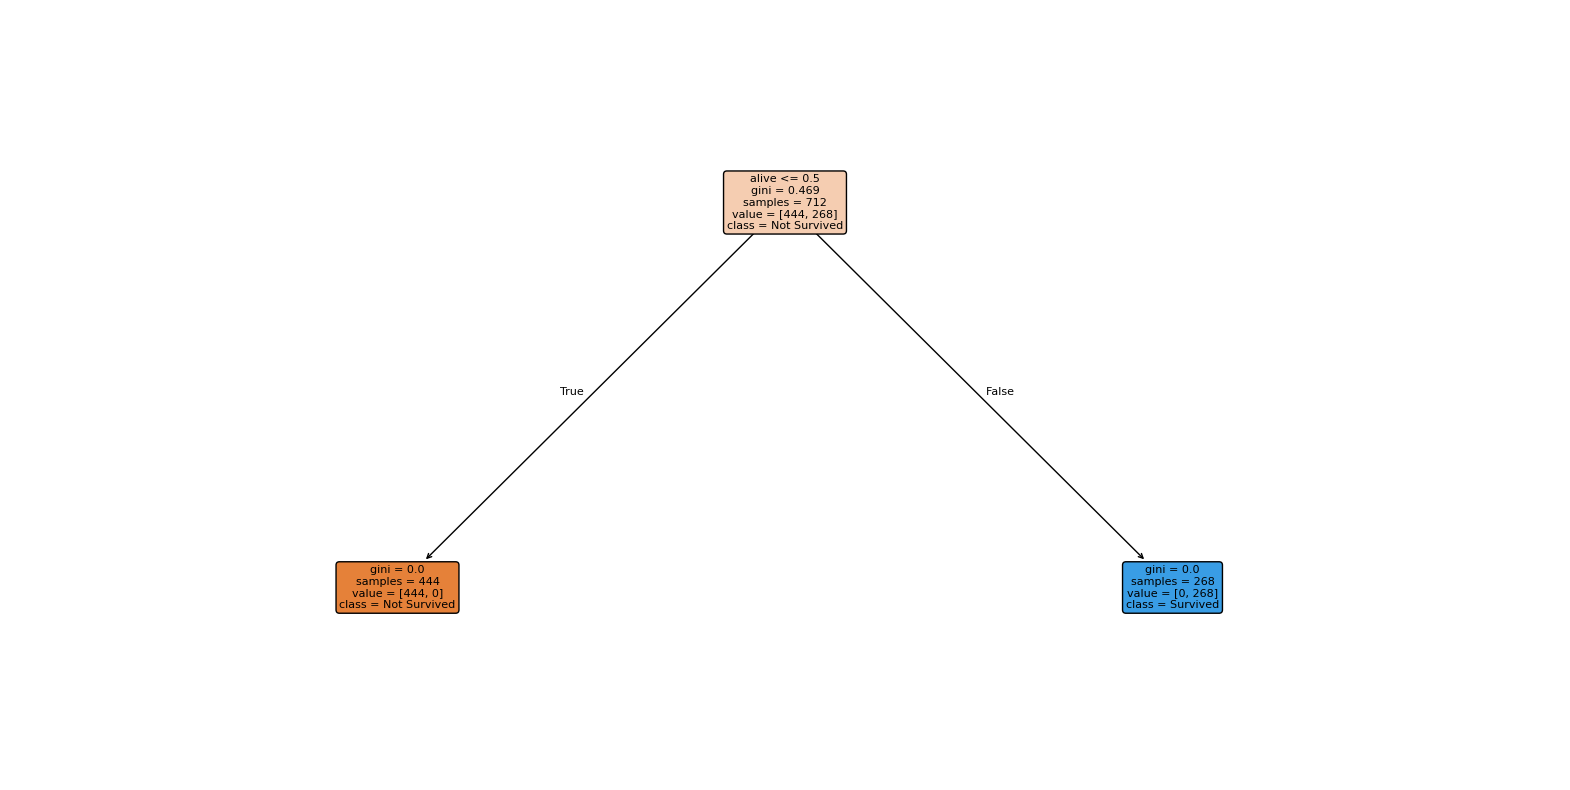

In [22]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived","Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

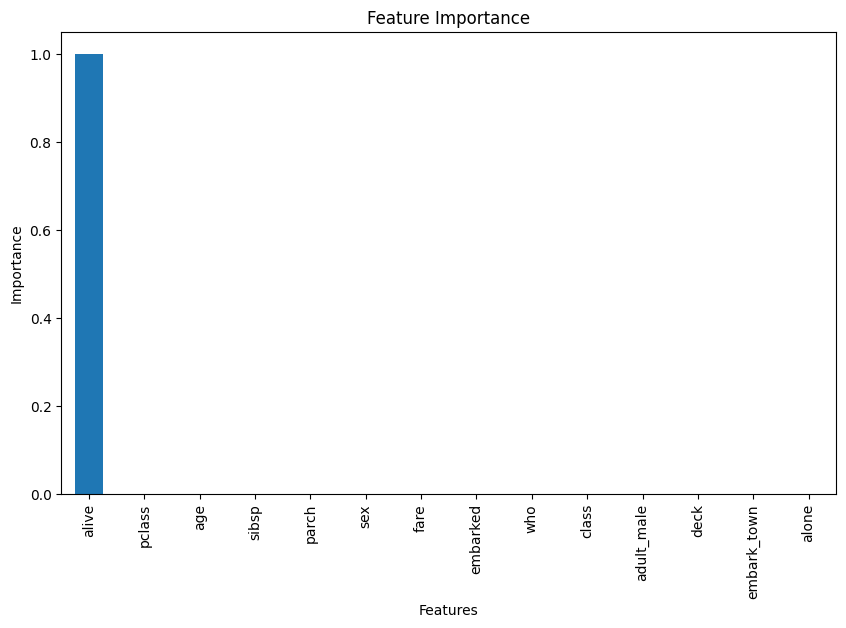

In [23]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [24]:
# Conclusion

- Loaded the Titanic dataset.
- Cleaned missing values.
- Encoded categorical variables using LabelEncoder.
- Split the dataset into training and testing sets.
- Built a Decision Tree Classifier.
- Evaluated the model using Accuracy, Confusion Matrix, and Classification Report.
- Visualized the Decision Tree and Feature Importance.

SyntaxError: invalid syntax (1605902119.py, line 3)